# Airbnb Host Analytics
The aim of this notebook is to explore how the characteristics of a host can affect the performance of their listings, specifically their occupancy rate in the next 30 days.

## Import Libraries

In [1]:
# Import libraries
import requests
import gzip
import shutil
import pandas as pd
import string
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
import duckdb
import seaborn as sns

## Load Dataset

In [2]:
# Download data file
url = 'http://data.insideairbnb.com/australia/vic/melbourne/2023-03-13/data/listings.csv.gz'
response = requests.get(url, stream=True)

# Unzip file
with open('listings.csv.gz', 'wb') as f:
    response.raw.decode_content = True
    shutil.copyfileobj(response.raw, f)

with gzip.open('listings.csv.gz', 'rb') as f_in:
    with open('listings.csv', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

# Load unzipped CSV dataset into dataframe
df = pd.read_csv('listings.csv')

In [3]:
# Check dataframe
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,284210,https://www.airbnb.com/rooms/284210,20230313171244,2023-03-14,previous scrape,Fitzroyalty - stylish and central,"In the heart of Fitzroy, immerse yourself in t...",I love Fitzroy because is is walking distance ...,https://a0.muscache.com/pictures/225774e1-bb72...,1480426,...,4.85,4.97,4.61,NaN,f,1,1,0,0,0.31
1,999067,https://www.airbnb.com/rooms/999067,20230313171244,2023-03-14,city scrape,"The Stables, Richmond",Superbly located hotel style accommodation in ...,Richmond is a great neighbourhood. A beautifu...,https://a0.muscache.com/pictures/miso/Hosting-...,5491435,...,4.93,4.93,4.82,NaN,f,2,2,0,0,6.11
2,10803,https://www.airbnb.com/rooms/10803,20230313171244,2023-03-14,city scrape,Room in Cool Deco Apartment in Brunswick East,A large air conditioned room with firm queen s...,This hip area is a crossroads between two grea...,https://a0.muscache.com/pictures/e5f30dd1-ac57...,38901,...,4.69,4.65,4.60,NaN,f,1,0,1,0,1.37
3,12936,https://www.airbnb.com/rooms/12936,20230313171244,2023-03-14,previous scrape,St Kilda 1BR+BEACHSIDE+BALCONY+WIFI+AC,RIGHT IN THE HEART OF ST KILDA! It doesn't get...,A stay at our apartment means you can enjoy so...,https://a0.muscache.com/pictures/59701/2e8cdaf...,50121,...,4.83,4.78,4.66,NaN,f,10,10,0,0,0.27
4,289467,https://www.airbnb.com/rooms/289467,20230313171244,2023-03-13,city scrape,The Suite @ Angelus Retreat,<b>The space</b><br />Welcome to ANGELUS Retre...,NaN,https://a0.muscache.com/pictures/3243110/ace5b...,1448773,...,4.50,5.00,4.75,NaN,f,2,2,0,0,0.09


## Explore Data

In [4]:
# Check columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20768 entries, 0 to 20767
Data columns (total 75 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            20768 non-null  int64  
 1   listing_url                                   20768 non-null  object 
 2   scrape_id                                     20768 non-null  int64  
 3   last_scraped                                  20768 non-null  object 
 4   source                                        20768 non-null  object 
 5   name                                          20766 non-null  object 
 6   description                                   20394 non-null  object 
 7   neighborhood_overview                         12217 non-null  object 
 8   picture_url                                   20768 non-null  object 
 9   host_id                                       20768 non-null 

In [5]:
# Pick columns for the analytics
cols = [
    "last_scraped",
    "listing_url",
    "host_id",
    "host_since",
    "host_about",                             
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "neighbourhood_cleansed",
    "latitude",
    "longitude",
    "room_type",
    "price",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "calculated_host_listings_count",
]

df_fil = df[cols].copy()

In [6]:
# Check dataframe
df_fil.head(5)

,last_scraped,listing_url,host_id,host_since,host_about,host_is_superhost,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,latitude,longitude,room_type,price,availability_30,availability_60,availability_90,availability_365,number_of_reviews,calculated_host_listings_count
0,2023-03-14,https://www.airbnb.com/rooms/284210,1480426,2011-12-07,I I love travelling and try to go on at least ...,f,t,t,Yarra,-37.79951,144.97948,Entire home/apt,$245.00,0,0,0,0,34,1
1,2023-03-14,https://www.airbnb.com/rooms/999067,5491435,2013-03-16,I'm a working mum who loves being able to shar...,f,t,t,Yarra,-37.82030,144.99016,Entire home/apt,$132.00,0,0,0,12,741,2
2,2023-03-14,https://www.airbnb.com/rooms/10803,38901,2009-09-16,As an artist working in animation and video I ...,f,t,t,Moreland,-37.76606,144.97951,Private room,$39.00,0,12,22,112,169,1
3,2023-03-14,https://www.airbnb.com/rooms/12936,50121,2009-10-31,NaN,f,t,t,Port Phillip,-37.85999,144.97662,Entire home/apt,$95.00,0,0,0,0,42,10
4,2023-03-13,https://www.airbnb.com/rooms/289467,1448773,2011-11-28,I have very special interests in Life and Life...,t,t,t,Yarra Ranges,-37.90546,145.39447,Entire home/apt,$270.00,30,60,90,365,8,2


### host_about
The number of words in host_about description is to be categorised based on its word counts. In processing the data, punctuations and stop words are to be removed to only count meaningful words.

In [7]:
# Remove punctuations and stop words from text and count the words
## Define a list of punctuations and stop words to remove from text
punctuations = string.punctuation
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
remove_li = []
remove_li.append(punctuations)
remove_li.append(list(stop_words))

def count_meaningful_words(text):
    # If input is not a string, return 0
    if type(text) != str:
        return 0
    
    # Remove punctuations and stop words and split into a list
    text_fil = text.translate(str.maketrans('', '', string.punctuation)).split()
    
    return len(text_fil)

df_fil["host_about_word_count"] = df_fil["host_about"].apply(lambda x: count_meaningful_words(x))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bog74\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


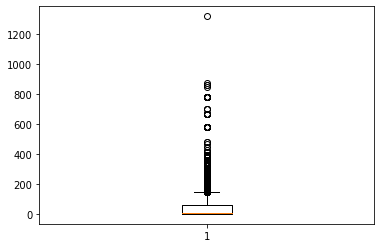

In [8]:
# Check boxplot of the word counts
bp = plt.boxplot(df_fil["host_about_word_count"])

In [9]:
# Check boxplot measurements
for key in bp:
    print(f'{key}: {[item.get_ydata() for item in bp[key]]}\n')

whiskers: [array([0., 0.]), array([ 59., 147.])]

caps: [array([0, 0], dtype=int64), array([147, 147], dtype=int64)]

boxes: [array([ 0.,  0., 59., 59.,  0.])]

medians: [array([8., 8.])]

fliers: [array([247, 159, 203, ..., 148, 170, 338], dtype=int64)]

means: []



Upon checking the boxplot, the statistics are:
- Lower whisker: 0
- 25th percentile: 0
- 50th percentile: 8
- 75th percentile: 59
- Upper whisker: 147

##### Category: No description (0)

In [10]:
# Inspect host_about where word cound is nil
print(df_fil.loc[
    (df_fil["host_about_word_count"] == 0) 
]["host_about"].count())

df_fil.loc[
    (df_fil["host_about_word_count"] == 0) 
]["host_about"].tolist()[0]

51


nan

##### Category: Short (0 - 2Q)

In [11]:
# Inspect host_about where word cound is equal to or less than 0 but greater than 0
print(df_fil.loc[
    (df_fil["host_about_word_count"] <= 8) 
    & (df_fil["host_about_word_count"] > 0)
]["host_about"].count())

df_fil.loc[
    (df_fil["host_about_word_count"] <= 8) 
    & (df_fil["host_about_word_count"] > 0)
]["host_about"].tolist()[0]

1134


'Easygoing and friendly - love life!'

##### Category: Concise (2Q - 3Q)

In [12]:
# Inspect host_about where word cound is greater than 8 but equal to or less than 59
print(df_fil.loc[
    (df_fil["host_about_word_count"] > 8) 
    &(df_fil["host_about_word_count"] <= 59)
]["host_about"].count())

df_fil.loc[
    (df_fil["host_about_word_count"] > 8) 
    &(df_fil["host_about_word_count"] <= 59)
]["host_about"].tolist()[0]

5181


'I I love travelling and try to go on at least one big adventure a year.  When I do I love staying with Airbnb and meeting new people along the way.'

##### Category: Detailed (3Q - UPPER LIMIT)

In [13]:
# Inspect host_about where word cound is greater than 59 but less than 147
print(df_fil.loc[
    (df_fil["host_about_word_count"] > 59) 
    &(df_fil["host_about_word_count"] <= 147)
]["host_about"].count())

df_fil.loc[
    (df_fil["host_about_word_count"] > 59) 
    &(df_fil["host_about_word_count"] <= 147)
]["host_about"].tolist()[0]

3512


"As an artist working in animation and video I am involved in many community related projects. I manage a Yoga studio at this address, downstairs from the flat. I really enjoy Yoga, good food, good company and getting out into the sunshine whenever I can. Melbourne is a great city of arts and music - there's always something on and my flat is in a great location between Brunswick and Northcote, two suburbs with many arts warehouses and venues. Please be aware that the apartment is old and has a funky vibe and it is not for people who need  modern hotel style accommodation. "

##### Category: Lengthy (> UPPER LIMIT)

In [14]:
# Inspect host_about where word cound is greater than 147
print(df_fil.loc[
    (df_fil["host_about_word_count"] > 147) 
]["host_about"].count())

df_fil.loc[
    (df_fil["host_about_word_count"] > 147)
]["host_about"].tolist()[0]

1673


'I have very special interests in Life and Life matters. I love to cook, travel, hear your life experiences & stories and connect with people from our hearts. I love being the helper for people\'s shining. Recently I\'ve come back from a near death experience riding the rapids of the mighty Zambezi at Victoria Falls - with a renewed sense of purpose and feeling inspired.\r\n\r\nHaving had conventional medical and alternative, complementary medicine practice of 30 +yrs and more than 35,000 hours consultation experience, I am putting my message in a book and a program called "What our Bodies Ache For - uncovering repressed longings hidden in body symptoms, anxiety, depression and chronic illness"\r\nI would like to dispel the myths of current medical thinking and inspire our systems to work on the cause rather than just the symptoms. Preventative medicine is not just about screening physical bodies but need to address underlying dis-ease ( lack of ease) in our emotions, mind and spirit).

### price
While analysing the effect of host characteristics, to reduce the price factor, only listing within the price range between median and upper whisker is considered.

whiskers: [array([99.,  0.]), array([250., 476.])]

caps: [array([0., 0.]), array([476., 476.])]

boxes: [array([ 99.,  99., 250., 250.,  99.])]

medians: [array([160., 160.])]

fliers: [array([1000.,  567.,  494., ...,  568.,  640.,  700.])]

means: []



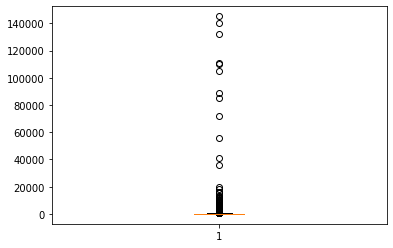

In [15]:
# Remove dollar sign and convert to float
df_fil["price_digit"] = df_fil["price"].apply(lambda x: float(x.replace("$", "").replace(",", "")))

# Plot boxplot
bp = plt.boxplot(df_fil["price_digit"])

# Check boxplot measurements
for key in bp:
    print(f'{key}: {[item.get_ydata() for item in bp[key]]}\n')

In [16]:
# Count listings within the price range
price_within_cnt = df_fil.loc[
    (df_fil["price_digit"] >= 160) & (df_fil["price_digit"] <= 476)
]["price"].count()

print(price_within_cnt)

8845


## Data Modelling
Prior to data modelling, the raw dataset is processed.

Then the processed dataset is used to create a data mart, followed by a metric layer for data visualisation.

The data modelling is conducted in SQL using DuckDB.

### Process dataset
The raw dataset is processed to filter the data based on the following conditions:
- Host identity must be verified for valid hosts
- Room availability for next 60, 90 and 365 days must not be zero to ensure only available listings are used
- Municipality of the listing must be metropolitan municipalities to eliminate rural area effect
- Listing must be an entire home/apt to limit diversity of the listing type
- Price must be within the range between median and upper limit to filter out outliers and reduce price factor

Metropolitan Melbourne municipalities:
    Banyule,
Bayside,
Boroondara,
Brimbank,
Cardinia,
Casey,
Darebin,
Frankston,
Glen Eira,
Greater Dandenong,
Hobsons Bay,
Hume,
Kingston,
Knox,
Manningham,
Maribyrnong,
Maroondah,
Melbourne,
Melton,
Monash,
Moonee Valley,
Moreland,
Mornington Peninsula,
Nillumbik,
Port Phillip,
Stonnington,
Whitehorse,
Whittlesea,
Wyndham,
Yarra,
Yarra Ranges

In [17]:
# Process raw dataset
airbnb_processed = duckdb.sql("""
WITH BASE AS (
    SELECT
        CAST(STRPTIME(last_scraped, '%Y-%m-%d') AS DATE) AS SNAPSHOT_DATE,
        CAST(RIGHT(listing_url, POSITION('/' IN REVERSE(listing_url)) - 1) AS INT64) AS LISTING_ID,
        host_id AS HOST_ID,
        DATE_DIFF(
            'YEAR', 
            CAST(STRPTIME(host_since, '%Y-%m-%d') AS DATE),
            CURRENT_DATE
        ) AS HOST_YEAR_OF_EXP,
        CAST(
            LENGTH(RTRIM(LTRIM(host_about)))
            - LENGTH(REPLACE(RTRIM(LTRIM(host_about)), ' ', ''))
            + 1 
            AS NUMERIC
        ) AS HOST_ABOUT_WORD_COUNT,
        host_is_superhost AS IS_HOST_SUPERHOST,
        host_has_profile_pic AS HAS_HOST_PROFILE_PHOTO,
        calculated_host_listings_count AS HOST_LISTING_COUNT,
        latitude AS LISTING_LATITUDE,
        longitude AS LISTING_LONGITUDE,
        CAST(REPLACE(REPLACE(price, '$', ''), ',', '') AS NUMERIC) AS LISTING_PRICE,
        QUANTILE_CONT(
            CAST(REPLACE(REPLACE(price, '$', ''), ',', '') AS NUMERIC),
            0.50
        ) OVER() AS LISTING_PRICE_2Q,
        QUANTILE_CONT(
            CAST(REPLACE(REPLACE(price, '$', ''), ',', '') AS NUMERIC),
            0.75
        ) OVER() * 1.5 AS LISTING_PRICE_UPPER,
        ROUND((30 - CAST(availability_30 AS NUMERIC)) / 30 * 100, 0) AS LISTING_OCCUPANCY_RATE,
        number_of_reviews AS LISTING_REVIEW_COUNT,
        neighbourhood_cleansed AS LISTING_MUNICIPALITY
    FROM df
    WHERE 1=1
        AND host_identity_verified = 't'
        AND availability_60 <> 0
        AND availability_90 <> 0
        AND availability_365 <> 0
        AND LOWER(neighbourhood_cleansed) IN (
            'banyule',
            'bayside',
            'boroondara',
            'brimbank',
            'cardinia',
            'casey',
            'darebin',
            'frankston',
            'glen eira',
            'greater dandenong',
            'hobsons bay',
            'hume',
            'kingston',
            'knox',
            'manningham',
            'maribyrnong',
            'maroondah',
            'melbourne',
            'melton',
            'monash',
            'moonee valley',
            'moreland',
            'mornington peninsula',
            'nillumbik',
            'port phillip',
            'stonnington',
            'whitehorse',
            'whittlesea',
            'wyndham',
            'yarra',
            'yarra ranges'
        )
        AND LOWER(room_type) = 'entire home/apt'
)
SELECT
    SNAPSHOT_DATE,
    LISTING_ID,
    HOST_ID,
    HOST_YEAR_OF_EXP,
    HOST_ABOUT_WORD_COUNT,
    IS_HOST_SUPERHOST,
    HAS_HOST_PROFILE_PHOTO,
    HOST_LISTING_COUNT,
    LISTING_LATITUDE,
    LISTING_LONGITUDE,
    LISTING_OCCUPANCY_RATE,
    LISTING_PRICE,
    LISTING_REVIEW_COUNT,
    LISTING_MUNICIPALITY
FROM BASE
WHERE 1=1
    AND LISTING_PRICE >= LISTING_PRICE_2Q
    AND LISTING_PRICE <= LISTING_PRICE_UPPER
""")

airbnb_processed.to_csv("airbnb_process.csv")

airbnb_processed

┌───────────────┬────────────────────┬───────────┬───┬───────────────┬──────────────────────┬──────────────────────┐
│ SNAPSHOT_DATE │     LISTING_ID     │  HOST_ID  │ … │ LISTING_PRICE │ LISTING_REVIEW_COUNT │ LISTING_MUNICIPALITY │
│     date      │       int64        │   int64   │   │ decimal(18,3) │        int64         │       varchar        │
├───────────────┼────────────────────┼───────────┼───┼───────────────┼──────────────────────┼──────────────────────┤
│ 2023-03-13    │             289467 │   1448773 │ … │       270.000 │                    8 │ Yarra Ranges         │
│ 2023-03-14    │            1061196 │   1701103 │ … │       336.000 │                   95 │ Yarra                │
│ 2023-03-13    │            1067281 │   5869866 │ … │       349.000 │                    6 │ Kingston             │
│ 2023-03-14    │              51592 │    190879 │ … │       329.000 │                  394 │ Melbourne            │
│ 2023-03-13    │            1107707 │   5869866 │ … │       359

### Create Data Mart
The data mart will contain the following fact and dimensional tables.

- airbnb_fact_occupancy: <br>
        id, 
        listing_id, 
        host_id, 
        occupancy_rate, 
        snapshot_date
    
- airbnb_dim_host: 
        host_id, 
        is_super_host,
        has_profile_photo,
        about_word_count,
        year_of_exp, 
        listing_count
    
- airbnb_dim_listing: 
        listing_id, 
        municipality, 
        latitude, 
        longitude, 
        price,
        review_count

#### airbnb_dim_host
    host_id, 
    is_super_host,
    has_profile_photo,
    about_word_count,
    year_of_exp, 
    listing_count

In [45]:
# Model airbnb_dim_host
airbnb_dim_host = duckdb.sql("""
WITH BASE AS (
    SELECT DISTINCT
        HOST_ID,
        IS_HOST_SUPERHOST,
        HAS_HOST_PROFILE_PHOTO,
        HOST_ABOUT_WORD_COUNT,
        HOST_YEAR_OF_EXP,
        HOST_LISTING_COUNT
    FROM airbnb_processed
    WHERE 1=1
)
SELECT
    HOST_ID,
    CASE
        WHEN IS_HOST_SUPERHOST = 't' THEN 'Y'
        WHEN IS_HOST_SUPERHOST = 'f' THEN 'N'
        ELSE NULL
    END AS IS_HOST_SUPERHOST,
    CASE
        WHEN HAS_HOST_PROFILE_PHOTO = 't' THEN 'Y'
        WHEN HAS_HOST_PROFILE_PHOTO = 'f' THEN 'N'
        ELSE NULL
    END AS HAS_HOST_PROFILE_PHOTO,
    HOST_ABOUT_WORD_COUNT,
    HOST_YEAR_OF_EXP,
    HOST_LISTING_COUNT
FROM BASE
""")

# export to CSV file
airbnb_dim_host.write_csv('airbnb_dim_host.csv')

# Inspect table
airbnb_dim_host

┌───────────┬───────────────────┬──────────────────────┬───────────────────────┬──────────────────┬────────────────────┐
│  HOST_ID  │ IS_HOST_SUPERHOST │ HAS_HOST_PROFILE_P…  │ HOST_ABOUT_WORD_COUNT │ HOST_YEAR_OF_EXP │ HOST_LISTING_COUNT │
│   int64   │      varchar      │       varchar        │     decimal(18,3)     │      int64       │       int64        │
├───────────┼───────────────────┼──────────────────────┼───────────────────────┼──────────────────┼────────────────────┤
│   1448773 │ Y                 │ Y                    │               249.000 │               12 │                  2 │
│   1701103 │ N                 │ Y                    │                93.000 │               11 │                  1 │
│   5869866 │ N                 │ Y                    │                57.000 │               10 │                  3 │
│    190879 │ Y                 │ Y                    │               111.000 │               13 │                  1 │
│   4517777 │ N                 

#### airbnb_dim_listing
    listing_id, 
    municipality, 
    latitude, 
    longitude, 
    price,
    review_count

In [46]:
# Model airbnb_dim_listing
airbnb_dim_listing = duckdb.sql("""
SELECT DISTINCT
    LISTING_ID,
    LISTING_MUNICIPALITY,
    LISTING_LATITUDE,
    LISTING_LONGITUDE,
    LISTING_PRICE,
    LISTING_REVIEW_COUNT
FROM airbnb_processed
""")

# export to CSV file
airbnb_dim_listing.write_csv('airbnb_dim_listing.csv')

# Inspect table
airbnb_dim_listing

┌────────────────────┬──────────────────────┬────────────────────┬───┬───────────────┬──────────────────────┐
│     LISTING_ID     │ LISTING_MUNICIPALITY │  LISTING_LATITUDE  │ … │ LISTING_PRICE │ LISTING_REVIEW_COUNT │
│       int64        │       varchar        │       double       │   │ decimal(18,3) │        int64         │
├────────────────────┼──────────────────────┼────────────────────┼───┼───────────────┼──────────────────────┤
│             289467 │ Yarra Ranges         │          -37.90546 │ … │       270.000 │                    8 │
│            1061196 │ Yarra                │          -37.80087 │ … │       336.000 │                   95 │
│            1067281 │ Kingston             │          -37.95697 │ … │       349.000 │                    6 │
│              51592 │ Melbourne            │          -37.81266 │ … │       329.000 │                  394 │
│            1107707 │ Bayside              │          -37.97205 │ … │       359.000 │                    7 │
│         

#### airbnb_fact_occupancy
    id, 
    listing_id, 
    host_id, 
    occupancy_rate, 
    snapshot_date

In [47]:
# Model airbnb_fact_occupancy
airbnb_fact_occupancy = duckdb.sql("""
SELECT DISTINCT
    ROW_NUMBER() OVER() AS ID,
    LISTING_ID,
    HOST_ID,
    LISTING_OCCUPANCY_RATE,
    SNAPSHOT_DATE
FROM airbnb_processed
""")

# export to CSV file
airbnb_fact_occupancy.write_csv('airbnb_fact_occupancy.csv')

# Inspect table
airbnb_fact_occupancy

┌───────┬────────────────────┬───────────┬────────────────────────┬───────────────┐
│  ID   │     LISTING_ID     │  HOST_ID  │ LISTING_OCCUPANCY_RATE │ SNAPSHOT_DATE │
│ int64 │       int64        │   int64   │         double         │     date      │
├───────┼────────────────────┼───────────┼────────────────────────┼───────────────┤
│     1 │             289467 │   1448773 │                    0.0 │ 2023-03-13    │
│     2 │            1061196 │   1701103 │                   93.0 │ 2023-03-14    │
│     3 │            1067281 │   5869866 │                  100.0 │ 2023-03-13    │
│     4 │              51592 │    190879 │                   77.0 │ 2023-03-14    │
│     5 │            1107707 │   5869866 │                   60.0 │ 2023-03-13    │
│     6 │            1181117 │   4517777 │                  100.0 │ 2023-03-14    │
│     7 │              74324 │    390761 │                  100.0 │ 2023-03-14    │
│     8 │              86369 │    246509 │                   30.0 │ 2023-03-

### Create Metric Layer

In [60]:
# Model airbnb_metric_host_occupancy
airbnb_metric_host_occupancy = duckdb.sql("""
WITH BASE AS (
    SELECT
        FACT.HOST_ID,
        CASE
            WHEN HOST.HOST_LISTING_COUNT > 1 THEN 'Y'
            WHEN HOST.HOST_LISTING_COUNT = 1 THEN 'N'
            ELSE NULL
        END AS IS_MULTI_LISTING,
        CASE
            WHEN HOST.HOST_YEAR_OF_EXP = 0 THEN '0'
            WHEN HOST.HOST_YEAR_OF_EXP > 0 AND HOST.HOST_YEAR_OF_EXP <= 4 THEN '0-4'
            WHEN HOST.HOST_YEAR_OF_EXP > 4 AND HOST.HOST_YEAR_OF_EXP <= 7 THEN '4-7'
            WHEN HOST.HOST_YEAR_OF_EXP > 7 AND HOST.HOST_YEAR_OF_EXP <= 10 THEN '7-10'
            WHEN HOST.HOST_YEAR_OF_EXP > 10 THEN '>10'
            ELSE NULL
        END AS YEAR_OF_EXP_CATEGORY,
        HOST.HAS_HOST_PROFILE_PHOTO AS HAS_PROFILE_PHOTO,
        HOST.IS_HOST_SUPERHOST AS IS_SUPERHOST,
        SUM(LISTING.LISTING_REVIEW_COUNT) OVER(PARTITION BY FACT.HOST_ID) AS TOTAL_REVIEW_COUNT,
        HOST.HOST_ABOUT_WORD_COUNT,
        QUANTILE_CONT(HOST.HOST_ABOUT_WORD_COUNT, 0.50) OVER() AS HOST_ABOUT_WORD_COUNT_2Q,
        QUANTILE_CONT(HOST.HOST_ABOUT_WORD_COUNT, 0.75) OVER() AS HOST_ABOUT_WORD_COUNT_3Q,
        QUANTILE_CONT(HOST.HOST_ABOUT_WORD_COUNT, 0.75) OVER() * 1.5 AS HOST_ABOUT_WORD_COUNT_UPPER,
        FACT.LISTING_OCCUPANCY_RATE AS OCCUPANCY_RATE,
        FACT.SNAPSHOT_DATE
    FROM airbnb_fact_occupancy FACT
    INNER JOIN airbnb_dim_host HOST 
        ON FACT.HOST_ID = HOST.HOST_ID
    INNER JOIN airbnb_dim_listing LISTING
        ON FACT.LISTING_ID = LISTING.LISTING_ID
)
SELECT
    HOST_ID,
    IS_MULTI_LISTING,
    YEAR_OF_EXP_CATEGORY,
    HAS_PROFILE_PHOTO,
    IS_SUPERHOST,
    CASE
        WHEN TOTAL_REVIEW_COUNT = 0 THEN '0'
        WHEN TOTAL_REVIEW_COUNT > 0 AND TOTAL_REVIEW_COUNT <= 10 THEN '1-10'
        WHEN TOTAL_REVIEW_COUNT > 10 AND TOTAL_REVIEW_COUNT <= 50 THEN '10-50'
        WHEN TOTAL_REVIEW_COUNT > 50 AND TOTAL_REVIEW_COUNT <= 100 THEN '50-100'
        WHEN TOTAL_REVIEW_COUNT > 100 THEN '>100'
    END AS TOTAL_REVIEW_CATEGORY,
    CASE
        WHEN HOST_ABOUT_WORD_COUNT = 0 THEN 'No Description'
        WHEN HOST_ABOUT_WORD_COUNT > 0
            AND HOST_ABOUT_WORD_COUNT <= HOST_ABOUT_WORD_COUNT_2Q THEN 'Short'
        WHEN HOST_ABOUT_WORD_COUNT > HOST_ABOUT_WORD_COUNT_2Q
            AND HOST_ABOUT_WORD_COUNT <= HOST_ABOUT_WORD_COUNT_3Q THEN 'Concise'
        WHEN HOST_ABOUT_WORD_COUNT > HOST_ABOUT_WORD_COUNT_3Q
            AND HOST_ABOUT_WORD_COUNT <= HOST_ABOUT_WORD_COUNT_UPPER THEN 'Detailed'
        WHEN HOST_ABOUT_WORD_COUNT > HOST_ABOUT_WORD_COUNT_UPPER THEN 'Lengthy'
    END AS HOST_ABOUT_CATEGORY,
    OCCUPANCY_RATE,
    SNAPSHOT_DATE
FROM BASE    
""")

# Expore to CSV file
airbnb_metric_host_occupancy.to_csv("airbnb_metric_host_occupancy.csv")

# Inspect table
airbnb_metric_host_occupancy

┌───────────┬──────────────────┬──────────────────────┬───┬─────────────────────┬────────────────┬───────────────┐
│  HOST_ID  │ IS_MULTI_LISTING │ YEAR_OF_EXP_CATEGORY │ … │ HOST_ABOUT_CATEGORY │ OCCUPANCY_RATE │ SNAPSHOT_DATE │
│   int64   │     varchar      │       varchar        │   │       varchar       │     double     │     date      │
├───────────┼──────────────────┼──────────────────────┼───┼─────────────────────┼────────────────┼───────────────┤
│    932976 │ Y                │ >10                  │ … │ Concise             │           67.0 │ 2023-03-13    │
│   2761952 │ N                │ >10                  │ … │ Short               │           67.0 │ 2023-03-14    │
│   3495733 │ N                │ >10                  │ … │ Short               │           77.0 │ 2023-03-14    │
│   3570625 │ Y                │ >10                  │ … │ Lengthy             │           20.0 │ 2023-03-14    │
│   3570625 │ Y                │ >10                  │ … │ Lengthy             

### Schemas

In [21]:
# Print schema of processed table
duckdb.sql("describe table airbnb_processed")

┌────────────────────────┬───────────────┬─────────┬─────────┬─────────┬─────────┐
│      column_name       │  column_type  │  null   │   key   │ default │  extra  │
│        varchar         │    varchar    │ varchar │ varchar │ varchar │ varchar │
├────────────────────────┼───────────────┼─────────┼─────────┼─────────┼─────────┤
│ SNAPSHOT_DATE          │ DATE          │ YES     │ NULL    │ NULL    │ NULL    │
│ LISTING_ID             │ BIGINT        │ YES     │ NULL    │ NULL    │ NULL    │
│ HOST_ID                │ BIGINT        │ YES     │ NULL    │ NULL    │ NULL    │
│ HOST_YEAR_OF_EXP       │ BIGINT        │ YES     │ NULL    │ NULL    │ NULL    │
│ HOST_ABOUT_WORD_COUNT  │ DECIMAL(18,3) │ YES     │ NULL    │ NULL    │ NULL    │
│ IS_HOST_SUPERHOST      │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ HAS_HOST_PROFILE_PHOTO │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ HOST_LISTING_COUNT     │ BIGINT        │ YES     │ NULL    │ NULL    │ NULL    │
│ LI

In [22]:
# Print schema of dim host table
duckdb.sql("describe table airbnb_dim_host")

┌────────────────────────┬───────────────┬─────────┬─────────┬─────────┬─────────┐
│      column_name       │  column_type  │  null   │   key   │ default │  extra  │
│        varchar         │    varchar    │ varchar │ varchar │ varchar │ varchar │
├────────────────────────┼───────────────┼─────────┼─────────┼─────────┼─────────┤
│ HOST_ID                │ BIGINT        │ YES     │ NULL    │ NULL    │ NULL    │
│ IS_HOST_SUPERHOST      │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ HAS_HOST_PROFILE_PHOTO │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ HOST_ABOUT_WORD_COUNT  │ DECIMAL(18,3) │ YES     │ NULL    │ NULL    │ NULL    │
│ HOST_YEAR_OF_EXP       │ BIGINT        │ YES     │ NULL    │ NULL    │ NULL    │
│ HOST_LISTING_COUNT     │ BIGINT        │ YES     │ NULL    │ NULL    │ NULL    │
└────────────────────────┴───────────────┴─────────┴─────────┴─────────┴─────────┘

In [23]:
# Print schema of dim listing table
duckdb.sql("describe table airbnb_dim_listing")

┌──────────────────────┬───────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name      │  column_type  │  null   │   key   │ default │  extra  │
│       varchar        │    varchar    │ varchar │ varchar │ varchar │ varchar │
├──────────────────────┼───────────────┼─────────┼─────────┼─────────┼─────────┤
│ LISTING_ID           │ BIGINT        │ YES     │ NULL    │ NULL    │ NULL    │
│ LISTING_MUNICIPALITY │ VARCHAR       │ YES     │ NULL    │ NULL    │ NULL    │
│ LISTING_LATITUDE     │ DOUBLE        │ YES     │ NULL    │ NULL    │ NULL    │
│ LISTING_LONGITUDE    │ DOUBLE        │ YES     │ NULL    │ NULL    │ NULL    │
│ LISTING_PRICE        │ DECIMAL(18,3) │ YES     │ NULL    │ NULL    │ NULL    │
│ LISTING_REVIEW_COUNT │ BIGINT        │ YES     │ NULL    │ NULL    │ NULL    │
└──────────────────────┴───────────────┴─────────┴─────────┴─────────┴─────────┘

In [24]:
# Print schema of fact table
duckdb.sql("describe table airbnb_fact_occupancy")

┌────────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│      column_name       │ column_type │  null   │   key   │ default │  extra  │
│        varchar         │   varchar   │ varchar │ varchar │ varchar │ varchar │
├────────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ ID                     │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ LISTING_ID             │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ HOST_ID                │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ LISTING_OCCUPANCY_RATE │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ SNAPSHOT_DATE          │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
└────────────────────────┴─────────────┴─────────┴─────────┴─────────┴─────────┘

In [61]:
# Print schema of metric table
duckdb.sql("describe table airbnb_metric_host_occupancy")

┌───────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│      column_name      │ column_type │  null   │   key   │ default │  extra  │
│        varchar        │   varchar   │ varchar │ varchar │ varchar │ varchar │
├───────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ HOST_ID               │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ IS_MULTI_LISTING      │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ YEAR_OF_EXP_CATEGORY  │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ HAS_PROFILE_PHOTO     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ IS_SUPERHOST          │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ TOTAL_REVIEW_CATEGORY │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ HOST_ABOUT_CATEGORY   │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ OCCUPANCY_RATE        │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ SNAPSHOT_DATE         │ DATE        │ 

## Data Visualisations

In [62]:
# Convert DuckDB metric table to dataframe
df_metric = airbnb_metric_host_occupancy.to_df()

### Effect of multiple listings

<AxesSubplot:xlabel='IS_MULTI_LISTING', ylabel='OCCUPANCY_RATE'>

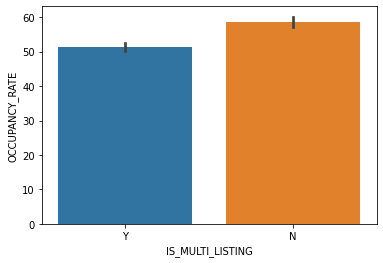

In [71]:
# Plot a chart
sns.barplot(data=df_metric, x="IS_MULTI_LISTING", y="OCCUPANCY_RATE")

In [95]:
# Count by values
df_metric["IS_MULTI_LISTING"].value_counts()

Y    2475
N    1350
Name: IS_MULTI_LISTING, dtype: int64

### Effect of host experience

<AxesSubplot:xlabel='OCCUPANCY_RATE', ylabel='YEAR_OF_EXP_CATEGORY'>

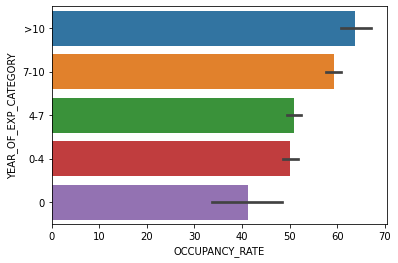

In [73]:
# Plot a chart
sns.barplot(data=df_metric, x="OCCUPANCY_RATE", y="YEAR_OF_EXP_CATEGORY")

In [96]:
# Count by values
df_metric["YEAR_OF_EXP_CATEGORY"].value_counts()

4-7     1246
0-4     1141
7-10    1124
>10      259
0         55
Name: YEAR_OF_EXP_CATEGORY, dtype: int64

### Effect of profile photo

<AxesSubplot:xlabel='HAS_PROFILE_PHOTO', ylabel='OCCUPANCY_RATE'>

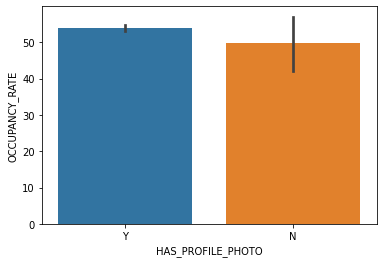

In [74]:
# Plot a chart
sns.barplot(data=df_metric, x="HAS_PROFILE_PHOTO", y="OCCUPANCY_RATE")

In [97]:
# Count by values
df_metric["HAS_PROFILE_PHOTO"].value_counts()

Y    3777
N      48
Name: HAS_PROFILE_PHOTO, dtype: int64

### Effect of number of total reviews

<AxesSubplot:xlabel='OCCUPANCY_RATE', ylabel='TOTAL_REVIEW_CATEGORY'>

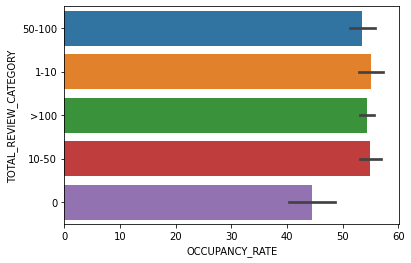

In [77]:
# Plot a chart
sns.barplot(data=df_metric, x="OCCUPANCY_RATE", y="TOTAL_REVIEW_CATEGORY")

In [98]:
# Count by values
df_metric["TOTAL_REVIEW_CATEGORY"].value_counts()

>100      1558
10-50      837
1-10       689
50-100     507
0          234
Name: TOTAL_REVIEW_CATEGORY, dtype: int64

### Effect of super host
Super host requires >4.8 review rating, >90% response rate, total of 100 stayed nights, <1% cancellation rate over the past 12 months

<AxesSubplot:xlabel='IS_SUPERHOST', ylabel='OCCUPANCY_RATE'>

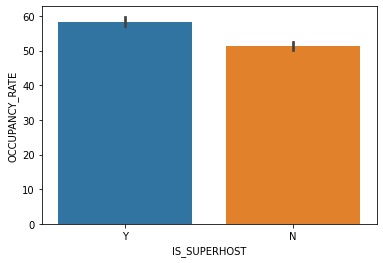

In [81]:
# Plot a chart
sns.barplot(data=df_metric, x="IS_SUPERHOST", y="OCCUPANCY_RATE")

In [99]:
# Count by values
df_metric["IS_SUPERHOST"].value_counts()

N    2420
Y    1405
Name: IS_SUPERHOST, dtype: int64

### Effect of host about (description)
- Short: 0 < word count <= median
- Concise: median < word count <= 75th percentile
- Detailed: 75th percentile < word count <= upper limit
- Lengthy: upper limit < word count 

<AxesSubplot:xlabel='OCCUPANCY_RATE', ylabel='HOST_ABOUT_CATEGORY'>

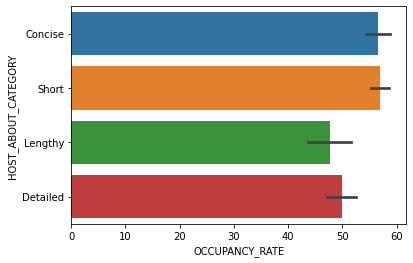

In [82]:
# Plot a chart
sns.barplot(data=df_metric, x="OCCUPANCY_RATE", y="HOST_ABOUT_CATEGORY")

In [100]:
# Count by values
df_metric["HOST_ABOUT_CATEGORY"].value_counts()

Short       1170
Concise      578
Detailed     374
Lengthy      208
Name: HOST_ABOUT_CATEGORY, dtype: int64

### Effect of winning attribute values
The occupancy rates of the hosts who have winning attribute values found above are compared against the occupancy rates against the rest of the hosts.

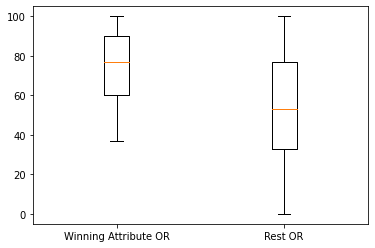

In [127]:
# Get occupancy rates of hosts with winning attribute values
df_winning_or = df_metric.loc[
    (df_metric["IS_MULTI_LISTING"] == "N") &
    (df_metric["YEAR_OF_EXP_CATEGORY"] == ">10") &
    (df_metric["HAS_PROFILE_PHOTO"] == "Y") &
    (df_metric["TOTAL_REVIEW_CATEGORY"] != "0") &
    (df_metric["TOTAL_REVIEW_CATEGORY"] != "0") &
    (df_metric["IS_SUPERHOST"] == "Y") &
    (df_metric["HOST_ABOUT_CATEGORY"].isin(["Short", "Concise"]))
].copy()
winning_or = df_winning_or["OCCUPANCY_RATE"].tolist()

# Get occupancy rates of the rest of the hosts
winning_or_hosts = df_winning_or["HOST_ID"].tolist()
rest_or = df_metric.loc[~df_metric["HOST_ID"].isin(winning_or_hosts)]["OCCUPANCY_RATE"]

# Compare boxplots
plt.boxplot([winning_or, rest_or], labels=["Winning Attribute OR", "Rest OR"])
plt.show()